In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prksh830/suicide-dataset/generalized_suicide_dataset_with_domain.csv


In [4]:
!pip install transformers
!pip install sentencepiece
!pip install shap
!pip install lime
!pip install nrclex
!pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00


In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from transformers import (
    AutoTokenizer,
    AutoModel
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from textblob import TextBlob

from nrclex import NRCLex

import matplotlib.pyplot as plt

In [6]:
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [7]:
MODEL_NAME = "vinai/bertweet-base"

MAX_LEN = 128

BATCH_SIZE = 16

EPOCHS = 10

LEARNING_RATE = 2e-5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [8]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
!find /kaggle/input -name "*.csv"

/kaggle/input/datasets/prksh830/suicide-dataset/generalized_suicide_dataset_with_domain.csv


In [10]:
df = pd.read_csv(
    "/kaggle/input/datasets/prksh830/suicide-dataset/generalized_suicide_dataset_with_domain.csv"
)

print(df.head())

print(df.shape)

                                          clean_text  label  token_count  \
0  always made me feel worthless but all of a sud...      1           14   
1                      hope i die in my sleep tonite      1            7   
2         my life sucks just want to give up and cry      1           10   
3  breed of queensland male who should ve already...      1           49   
4  closer to killing myself everyday famsquad but...      1           14   

     domain  
0  dataset2  
1  dataset2  
2  dataset2  
3  dataset2  
4  dataset2  
(57306, 4)


In [11]:
def extract_emotion_features(text):

    emotion = NRCLex(text)

    scores = emotion.affect_frequencies

    sadness = scores.get("sadness", 0)

    fear = scores.get("fear", 0)

    anger = scores.get("anger", 0)

    disgust = scores.get("disgust", 0)

    joy = scores.get("joy", 0)

    trust = scores.get("trust", 0)

    return [
        sadness,
        fear,
        anger,
        disgust,
        joy,
        trust
    ]

In [12]:
from nrclex import NRCLex

In [13]:
def extract_emotion_features(text):

    emotion = NRCLex(text)

    scores = emotion.raw_emotion_scores

    emotions = [
        "sadness",
        "fear",
        "anger",
        "disgust",
        "joy",
        "trust"
    ]

    feature_vector = []

    for emo in emotions:

        if emo in scores:
            feature_vector.append(scores[emo])

        else:
            feature_vector.append(0)

    return feature_vector

In [14]:
sample = NRCLex("I feel hopeless")

print(dir(sample))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lexicon__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_build_word_affect', '_compute_top_emotions', '_resolve_lexicon', 'load_raw_text', 'load_token_list']


In [15]:
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
def extract_emotion_features(text):

    try:

        result = emotion_classifier(text[:512])[0]

        emotion_scores = {
            item['label']: item['score']
            for item in result
        }

        sadness = emotion_scores.get("sadness", 0)

        fear = emotion_scores.get("fear", 0)

        anger = emotion_scores.get("anger", 0)

        disgust = emotion_scores.get("disgust", 0)

        joy = emotion_scores.get("joy", 0)

        surprise = emotion_scores.get("surprise", 0)

        return [
            sadness,
            fear,
            anger,
            disgust,
            joy,
            surprise
        ]

    except:

        return [0, 0, 0, 0, 0, 0]

In [17]:
emotion_features = df["clean_text"].apply(
    extract_emotion_features
)

emotion_features = np.array(
    emotion_features.tolist()
)

print(emotion_features.shape)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


(57306, 6)


In [18]:
texts_list = df["clean_text"].astype(str).tolist()

results = emotion_classifier(
    texts_list[:],
    batch_size=32,
    truncation=True
)

In [19]:
emotion_features = []

for result in results:

    emotion_scores = {
        item['label']: item['score']
        for item in result
    }

    sadness = emotion_scores.get("sadness", 0)

    fear = emotion_scores.get("fear", 0)

    anger = emotion_scores.get("anger", 0)

    disgust = emotion_scores.get("disgust", 0)

    joy = emotion_scores.get("joy", 0)

    surprise = emotion_scores.get("surprise", 0)

    emotion_features.append([
        sadness,
        fear,
        anger,
        disgust,
        joy,
        surprise
    ])

emotion_features = np.array(
    emotion_features
)

print(emotion_features.shape)

(57306, 6)


In [20]:
def extract_behavioral_features(text):

    words = text.split()

    sentence_length = len(words)

    exclamation_count = text.count("!")

    question_count = text.count("?")

    first_person_count = (
        text.lower().count("i ")
        + text.lower().count("me ")
        + text.lower().count("my ")
    )

    negative_words = [
        "die",
        "death",
        "suicide",
        "kill",
        "hopeless",
        "worthless",
        "depressed",
        "pain"
    ]

    negative_count = sum(
        word in text.lower()
        for word in negative_words
    )

    return [
        sentence_length,
        exclamation_count,
        question_count,
        first_person_count,
        negative_count
    ]

In [21]:
behavioral_features = df["clean_text"].astype(str).apply(
    extract_behavioral_features
)

behavioral_features = np.array(
    behavioral_features.tolist()
)

print(behavioral_features.shape)

(57306, 5)


In [22]:
texts = df["clean_text"].astype(str).values

labels = df["label"].values

print(texts.shape)

print(labels.shape)

(57306,)
(57306,)


In [23]:
print(type(sentiment_features))

NameError: name 'sentiment_features' is not defined

In [24]:
from transformers import pipeline
import numpy as np

sentiment_classifier = pipeline(
    "sentiment-analysis"
)

sentiment_results = sentiment_classifier(
    texts,
    truncation=True
)

sentiment_features = []

for result in sentiment_results:

    if result['label'] == 'POSITIVE':
        sentiment_features.append([1, result['score']])

    else:
        sentiment_features.append([0, result['score']])

sentiment_features = np.array(
    sentiment_features
)

print(sentiment_features.shape)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).

In [25]:
print(df.columns)

Index(['clean_text', 'label', 'token_count', 'domain'], dtype='object')


In [26]:
df = pd.read_csv("/kaggle/input/datasets/prksh830/suicide-dataset/generalized_suicide_dataset_with_domain.csv")

In [27]:
print(df.head())

                                          clean_text  label  token_count  \
0  always made me feel worthless but all of a sud...      1           14   
1                      hope i die in my sleep tonite      1            7   
2         my life sucks just want to give up and cry      1           10   
3  breed of queensland male who should ve already...      1           49   
4  closer to killing myself everyday famsquad but...      1           14   

     domain  
0  dataset2  
1  dataset2  
2  dataset2  
3  dataset2  
4  dataset2  


In [28]:
print(df.columns)

Index(['clean_text', 'label', 'token_count', 'domain'], dtype='object')


In [29]:
texts = df['text'].astype(str).tolist()

labels = df['label'].values

KeyError: 'text'

In [30]:
print(df.columns)

Index(['clean_text', 'label', 'token_count', 'domain'], dtype='object')


In [32]:
texts = df['clean_text'].astype(str).tolist()

labels = df['label'].values

In [33]:
print(len(texts))

print(len(labels))

57306
57306


In [35]:
texts = df['clean_text'].astype(str).tolist()

labels = df['label'].values

In [36]:
from transformers import pipeline
import numpy as np

sentiment_classifier = pipeline(
    "sentiment-analysis"
)

sentiment_results = sentiment_classifier(
    texts,
    truncation=True
)

sentiment_features = []

for result in sentiment_results:

    if result['label'] == 'POSITIVE':

        sentiment_features.append([
            1,
            result['score']
        ])

    else:

        sentiment_features.append([
            0,
            result['score']
        ])

sentiment_features = np.array(
    sentiment_features
)

print(sentiment_features.shape)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

(57306, 2)


In [38]:
print(emotion_features.shape)

print(sentiment_features.shape)

print(behavioral_features.shape)

(57306, 6)
(57306, 2)
(57306, 5)


In [41]:
from sklearn.model_selection import train_test_split

(
    train_texts,
    test_texts,
    train_labels,
    test_labels,
    train_emotion,
    test_emotion,
    train_sentiment,
    test_sentiment,
    train_behavior,
    test_behavior
) = train_test_split(

    texts,
    labels,
    emotion_features,
    sentiment_features,
    behavioral_features,

    test_size=0.2,

    stratify=labels,

    random_state=42
)

In [42]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=64
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [44]:
type(train_encodings)

transformers.tokenization_utils_base.BatchEncoding

In [45]:
train_input_ids = torch.tensor(
    train_encodings['input_ids']
)

train_attention_mask = torch.tensor(
    train_encodings['attention_mask']
)

In [46]:
import torch

train_input_ids = torch.tensor(
    train_encodings['input_ids']
)

train_attention_mask = torch.tensor(
    train_encodings['attention_mask']
)

test_input_ids = torch.tensor(
    test_encodings['input_ids']
)

test_attention_mask = torch.tensor(
    test_encodings['attention_mask']
)

train_labels_tensor = torch.tensor(
    train_labels
)

test_labels_tensor = torch.tensor(
    test_labels
)

In [47]:
train_emotion_tensor = torch.tensor(
    train_emotion,
    dtype=torch.float
)

test_emotion_tensor = torch.tensor(
    test_emotion,
    dtype=torch.float
)

train_sentiment_tensor = torch.tensor(
    train_sentiment,
    dtype=torch.float
)

test_sentiment_tensor = torch.tensor(
    test_sentiment,
    dtype=torch.float
)

train_behavior_tensor = torch.tensor(
    train_behavior,
    dtype=torch.float
)

test_behavior_tensor = torch.tensor(
    test_behavior,
    dtype=torch.float
)

In [48]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(

    train_input_ids,
    train_attention_mask,
    train_emotion_tensor,
    train_sentiment_tensor,
    train_behavior_tensor,
    train_labels_tensor
)

test_dataset = TensorDataset(

    test_input_ids,
    test_attention_mask,
    test_emotion_tensor,
    test_sentiment_tensor,
    test_behavior_tensor,
    test_labels_tensor
)

In [49]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)

In [50]:
import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-5
)

NameError: name 'model' is not defined

In [51]:
import torch.nn as nn
from transformers import BertModel

class HybridSuicideModel(nn.Module):

    def __init__(self):

        super(HybridSuicideModel, self).__init__()

        self.bert = BertModel.from_pretrained(
            'bert-base-uncased'
        )

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=128,
            batch_first=True,
            bidirectional=True
        )

        self.attention = nn.Linear(
            256,
            1
        )

        self.fc1 = nn.Linear(
            256 + 6 + 2 + 5,
            128
        )

        self.dropout = nn.Dropout(
            0.3
        )

        self.fc2 = nn.Linear(
            128,
            2
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        emotion,
        sentiment,
        behavior
    ):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state

        lstm_output, _ = self.lstm(
            sequence_output
        )

        attention_weights = torch.softmax(
            self.attention(lstm_output),
            dim=1
        )

        attention_output = torch.sum(
            attention_weights * lstm_output,
            dim=1
        )

        combined = torch.cat(
            (
                attention_output,
                emotion,
                sentiment,
                behavior
            ),
            dim=1
        )

        x = self.fc1(combined)

        x = torch.relu(x)

        x = self.dropout(x)

        logits = self.fc2(x)

        return logits

In [52]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model = HybridSuicideModel().to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [53]:
import torch

In [54]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model = HybridSuicideModel().to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [55]:
print(model)

HybridSuicideModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [57]:
import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [58]:
epochs = 2

model.train()

for epoch in range(epochs):

    total_loss = 0

    for batch in train_loader:

        input_ids = batch[0].to(device)

        attention_mask = batch[1].to(device)

        emotion = batch[2].to(device)

        sentiment = batch[3].to(device)

        behavior = batch[4].to(device)

        labels = batch[5].to(device)

        optimizer.zero_grad()

        outputs = model(

            input_ids,
            attention_mask,
            emotion,
            sentiment,
            behavior
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} Loss: {avg_loss}"
    )

Epoch 1 Loss: 0.24118107736932176
Epoch 2 Loss: 0.22721692406463867


In [59]:
model.eval()

predictions = []

true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[0].to(device)

        attention_mask = batch[1].to(device)

        emotion = batch[2].to(device)

        sentiment = batch[3].to(device)

        behavior = batch[4].to(device)

        labels = batch[5].to(device)

        outputs = model(

            input_ids,
            attention_mask,
            emotion,
            sentiment,
            behavior
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

In [60]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

accuracy = accuracy_score(
    true_labels,
    predictions
)

print("Accuracy:", accuracy)

print(
    classification_report(
        true_labels,
        predictions
    )
)

Accuracy: 0.9216541615773861
              precision    recall  f1-score   support

           0       0.62      0.15      0.25       957
           1       0.93      0.99      0.96     10505

    accuracy                           0.92     11462
   macro avg       0.78      0.57      0.60     11462
weighted avg       0.90      0.92      0.90     11462



In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[  148   809]
 [   89 10416]]


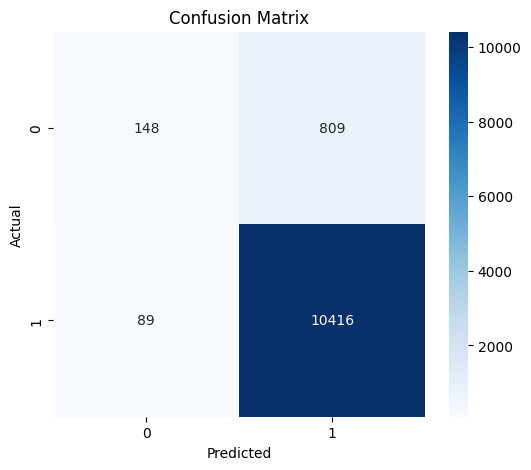

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

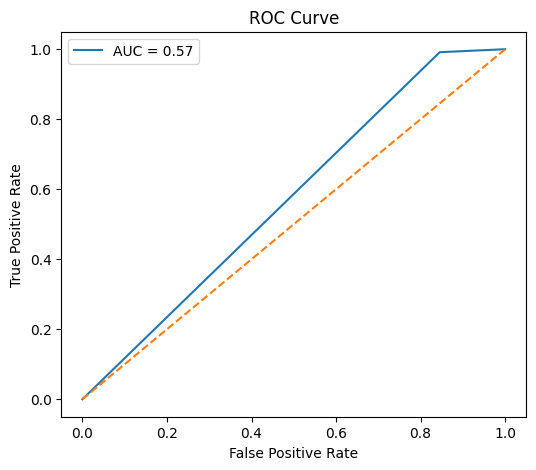

In [63]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    true_labels,
    predictions
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()